In [50]:
import pandas as pd
import numpy as np
import hyperopt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, precision_recall_curve, PrecisionRecallDisplay)
from sklearn.ensemble import IsolationForest
from sklearn.utils.class_weight import compute_sample_weight
from hyperopt import fmin, tpe, STATUS_OK, Trials

import xgboost as xgb
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


In [51]:
#in this cell, the data fron the csv will loaded into the dataframe and the different collumns will be categorized so that feature engineering can take place

df = pd.read_csv('insider_threat_clean_dataset.csv') #load data

cat_cols = ['employee_department', 'employee_campus', 'employee_position','employee_classification', 'employee_origin_country']

bin_cols = ['is_contractor', 'has_foreign_citizenship', 'has_criminal_record','has_medical_history', 'is_abroad', 'late_exit_flag','entry_during_weekend', 'burned_from_other']

num_cols = ['employee_seniority_years', 'total_printed_pages','num_printed_pages_off_hours', 'total_files_burned','trip_day_number', 'hostility_country_level', 'num_entries', 'num_unique_campus']

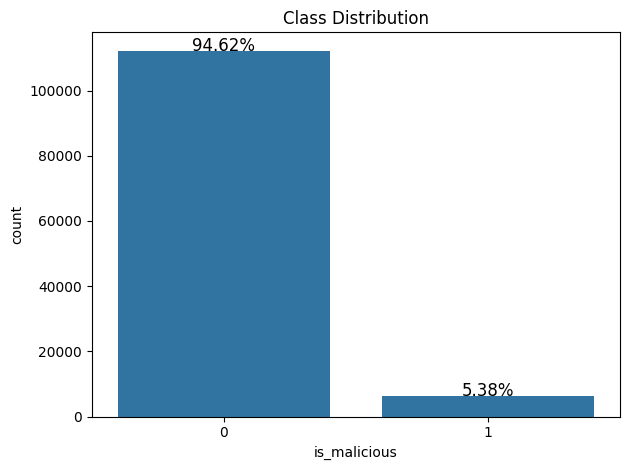

In [52]:
#data preprocessing: in order to have a balanced dataset and have a workable dataset, we will need to find any missing values and handle them in the most approiate manner
#no missing values so now it is time if we have an unbalanced dataset
df["is_malicious"].value_counts()

ax = sns.countplot(x='is_malicious', data=df)
for p in ax.patches:
    h = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2., h + 3,
            f'{h / len(df) * 100:.2f}%', ha='center', fontsize=12)
plt.title('Class Distribution')
plt.tight_layout()
plt.show()


In [53]:
#feature enginnering: here we are going to create some ratio features before we do any scaling

df['print_ratio'] = df['total_printed_pages']/df['num_printed_pages_off_hours']
df['file_ratio'] = df['total_files_burned']/df['num_printed_pages_off_hours']
df['risk_ratio'] = (df['has_criminal_record'] + df['is_contractor'] + df['has_foreign_citizenship'])
df["access_ratio"] = df['num_printed_pages_off_hours'] * df['entry_during_weekend']
df["afterhrs_ratio"] = df["late_exit_flag"] * df["num_printed_pages_off_hours"]

eng_num_cols = ['print_ratio', 'file_ratio','risk_ratio', 'access_ratio', 'afterhrs_ratio']

num_cols +=eng_num_cols

df[eng_num_cols] = df[eng_num_cols].replace([np.inf, -np.inf], np.nan)
df[eng_num_cols] = df[eng_num_cols].fillna(df[eng_num_cols].median())

# Encode categorical variables
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le




In [54]:
x = df.drop(columns=['is_malicious'])
y = df['is_malicious']
x_temp, x_test, y_temp, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
x_train, x_validation, y_train, y_val = train_test_split(x_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)#0.25 * 0.8 = 0.2 of total → 60/20/20

print(f"Training: {x_train.shape}, Validation: {x_validation.shape}, Testing: {x_test.shape}")
#this is done to prevnt any data leakage[x_test], allows for model to be tuned and check for overfitting

Training: (71168, 26), Validation: (23723, 26), Testing: (23723, 26)


In [55]:
scaler = StandardScaler()
x_train[num_cols] = scaler.fit_transform(x_train[num_cols])
x_validation[num_cols] = scaler.transform(x_validation[num_cols])
x_test[num_cols] = scaler.transform(x_test[num_cols])

In [56]:
for dataspilts in [x_train, x_validation, x_test]:
  dataspilts.replace([np.inf, -np.inf], np.nan, inplace=True)

In [57]:
from sklearn.utils import validation

isolation_forest_space = {
    'n_estimators': hyperopt.hp.choice('n_estimators', [50, 100, 150, 200]),
    'max_samples': hyperopt.hp.uniform('max_samples', 0.1, 1.0),
    "contamination": hyperopt.hp.uniform('contamination', 0.01, 0.5),
    "max_features": hyperopt.hp.uniform('max_features', 0.1, 1.0),
    "bootstrap": hyperopt.hp.choice('bootstrap', [True, False]),
}



In [58]:
def obj_iso(parameters):
  test_isolation_forest = IsolationForest(
      n_estimators=parameters['n_estimators'],
      max_samples=parameters['max_samples'],
      contamination=parameters['contamination'],
      max_features=parameters['max_features'],
      bootstrap=parameters['bootstrap'],
      random_state = 42,
      n_jobs = -1
  )

  test_isolation_forest.fit(x_train)
  test_iso_score =-np.mean(test_isolation_forest.score_samples(x_train))

  return {'loss': test_iso_score, 'status': STATUS_OK}


In [59]:
best_iso_values = fmin(
    fn=obj_iso,
    space=isolation_forest_space,
    algo=tpe.suggest,
    max_evals=50,
    rstate=np.random.default_rng(42)
)

100%|██████████| 50/50 [03:11<00:00,  3.83s/trial, best loss: 0.3985025835976449]


In [60]:
print("=====BEST HYPERPAREMETERS====")
print(best_iso_values)

=====BEST HYPERPAREMETERS====
{'bootstrap': np.int64(1), 'contamination': np.float64(0.1838165886169575), 'max_features': np.float64(0.7830927950341836), 'max_samples': np.float64(0.4893108514028392), 'n_estimators': np.int64(1)}


In [61]:
isolation_forest = IsolationForest(
    n_estimators=best_iso_values['n_estimators'],
    max_samples=best_iso_values['max_samples'],
    contamination=best_iso_values['contamination'],
    max_features=best_iso_values['max_features'],
    bootstrap=bool(best_iso_values['bootstrap']), # Explicitly convert to boolean
    n_jobs=-1,
    random_state=42
)

isolation_forest.fit(x_train)
#decsion_function was use to avoid hard logic erros
train_anomaly = isolation_forest.decision_function(x_train).reshape(-1,1)
test_anomaly = isolation_forest.decision_function(x_test).reshape(-1,1)
validation_anomaly = isolation_forest.decision_function(x_validation).reshape(-1,1)


In [62]:
x_append_train = np.hstack((x_train, train_anomaly))
x_append_test = np.hstack((x_test, test_anomaly))
x_append_validation = np.hstack((x_validation, validation_anomaly))

In [63]:
feature_columns = list(x_train.columns) + ['isolation_forest_anomaly_score']
print("Isolation Forest trained. Augmented feature count:", x_append_train.shape[1])

Isolation Forest trained. Augmented feature count: 27


In [75]:
xg_boost_space = {
    'n_estimators': hyperopt.hp.choice('n_estimators', [50, 100, 150, 200]),
    'max_depth': hyperopt.hp.choice('max_depth', [3, 5, 7, 10]),
    'learning_rate': hyperopt.hp.uniform('learning_rate', 0.01, 0.1),
    'subsample': hyperopt.hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hyperopt.hp.uniform('colsample_bytree', 0.5, 1.0),
    'scale_pos_weight': hyperopt.hp.uniform('scale_pos_weight', 10.0, 25.0), # Force model to focus on malicious class
    'random_state': 42,
    'eval_metric': 'logloss',
}

In [76]:
def obj_xg_boost(parameters):
    xg_boost_test = xgb.XGBClassifier(
        n_estimators=parameters['n_estimators'],
        max_depth=parameters['max_depth'],
        learning_rate=parameters['learning_rate'],
        subsample=parameters['subsample'],
        colsample_bytree=parameters['colsample_bytree'],
        scale_pos_weight=parameters['scale_pos_weight'],
        random_state=parameters['random_state'],
        eval_metric=parameters['eval_metric'],
        missing=np.nan,
        early_stopping_rounds=10,
    )

    xg_boost_test.fit(
        x_append_train, y_train,
        eval_set=[(x_append_validation, y_val)],
        verbose=False
    )


    predicts_val = xg_boost_test.predict(x_append_validation)

    #using F1-score instead of accuracy to handle class imbalance safely
    f1 = f1_score(y_val, predicts_val)

    return {"loss": 1 - f1, "status": STATUS_OK}

In [77]:
trials_xg_boost = Trials()
best_xg_boost_values = fmin(
    fn=obj_xg_boost,
    space=xg_boost_space,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials_xg_boost,
    rstate=np.random.default_rng(42)
)

100%|██████████| 50/50 [02:01<00:00,  2.43s/trial, best loss: 0.2258280361324858]


In [78]:
from hyperopt import space_eval
real_xg_best_params = space_eval(xg_boost_space, best_xg_boost_values)
print("\n===== TRUE BEST HYPERPARAMETERS =====")
print(real_xg_best_params)


===== TRUE BEST HYPERPARAMETERS =====
{'colsample_bytree': 0.7908502151494189, 'eval_metric': 'logloss', 'learning_rate': 0.08595580672514869, 'max_depth': 10, 'n_estimators': 150, 'random_state': 42, 'scale_pos_weight': 15.11842409661016, 'subsample': 0.9213882413406941}


In [79]:
#xgboost: this is will done first to get historcal indicators and a probability score of how closely an employee's profile matches past threats

xg_boost = xgb.XGBClassifier(
    **real_xg_best_params   ,
    missing=np.nan, # Explicitly tell XGBoost to treat NaN as missing values,
    early_stopping_rounds=10,
)

xg_boost.fit(
    x_append_train, y_train,
    eval_set=[(x_append_validation, y_val)],
    verbose=False
)



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7908502151494189, device=None,
              early_stopping_rounds=10, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.08595580672514869,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, ...)

In [80]:
validation_probability = xg_boost.predict_proba(x_append_validation)[:, 1]
predict,rec,thresholds = precision_recall_curve(y_val, validation_probability)

In [81]:
recall_target = 0.85
# Target recall ≥ 85% — prioritise catching threats over false-alarm reduction
target_recall = 0.85
idx = np.argmin(np.abs(rec[:-1] - target_recall))
best_threshold = thresholds[idx]
print(f"\nTuned threshold: {best_threshold:.4f}  (val recall ≈ {rec[idx]:.3f}, precision ≈ {predict[idx]:.3f})")



Tuned threshold: 0.6691  (val recall ≈ 0.850, precision ≈ 0.706)


In [82]:
test_probs = xg_boost.predict_proba(x_append_test)[:, 1]
test_preds = (test_probs >= best_threshold).astype(int)

accuracy  = accuracy_score(y_test, test_preds)
precision = precision_score(y_test, test_preds, zero_division=0)
recall    = recall_score(y_test, test_preds, zero_division=0)
f1        = f1_score(y_test, test_preds, zero_division=0)
cm        = confusion_matrix(y_test, test_preds)

tp = ((y_test == 1) & (test_preds == 1)).sum()
fp = ((y_test == 0) & (test_preds == 1)).sum()
fn = ((y_test == 1) & (test_preds == 0)).sum()
tn = ((y_test == 0) & (test_preds == 0)).sum()

print("\n" + "=" * 50)
print("TEST SET PERFORMANCE")
print("=" * 50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"\nTP: {tp}  FP: {fp}  FN: {fn}  TN: {tn}")
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:")
print(classification_report(y_test, test_preds, target_names=['Normal', 'Malicious']))


TEST SET PERFORMANCE
Accuracy:  0.9731
Precision: 0.7074
Recall:    0.8520
F1-Score:  0.7730

TP: 1088  FP: 450  FN: 189  TN: 21996

Confusion Matrix:
 [[21996   450]
 [  189  1088]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.98      0.99     22446
   Malicious       0.71      0.85      0.77      1277

    accuracy                           0.97     23723
   macro avg       0.85      0.92      0.88     23723
weighted avg       0.98      0.97      0.97     23723



In [83]:
#cross validation
# Create a new XGBClassifier instance without early stopping for cross-validation
xgb_cv_model = xgb.XGBClassifier(
    n_estimators=xg_boost.n_estimators,
    max_depth=xg_boost.max_depth,
    learning_rate=xg_boost.learning_rate,
    subsample=xg_boost.subsample,
    colsample_bytree=xg_boost.colsample_bytree,
    scale_pos_weight=xg_boost.scale_pos_weight,
    random_state=xg_boost.random_state,
    eval_metric=xg_boost.eval_metric,
    missing=xg_boost.missing,
    early_stopping_rounds=None  # Disable early stopping for cross-validation
)
cv_scores = cross_val_score(xgb_cv_model, x_append_train, y_train, cv=5, scoring='f1')
print(f"\nCross-validation F1: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print(f"Fold scores: {np.round(cv_scores, 4)}")


Cross-validation F1: 0.7765 (+/- 0.0185)
Fold scores: [0.7862 0.7733 0.7873 0.7623 0.7735]



Top 10 Features:
                feature  importance
      burned_from_other    0.178034
            print_ratio    0.120411
hostility_country_level    0.106640
     total_files_burned    0.091891
      num_unique_campus    0.055996
    total_printed_pages    0.039722
    has_criminal_record    0.036088
              is_abroad    0.031518
    employee_department    0.030575
employee_classification    0.026817


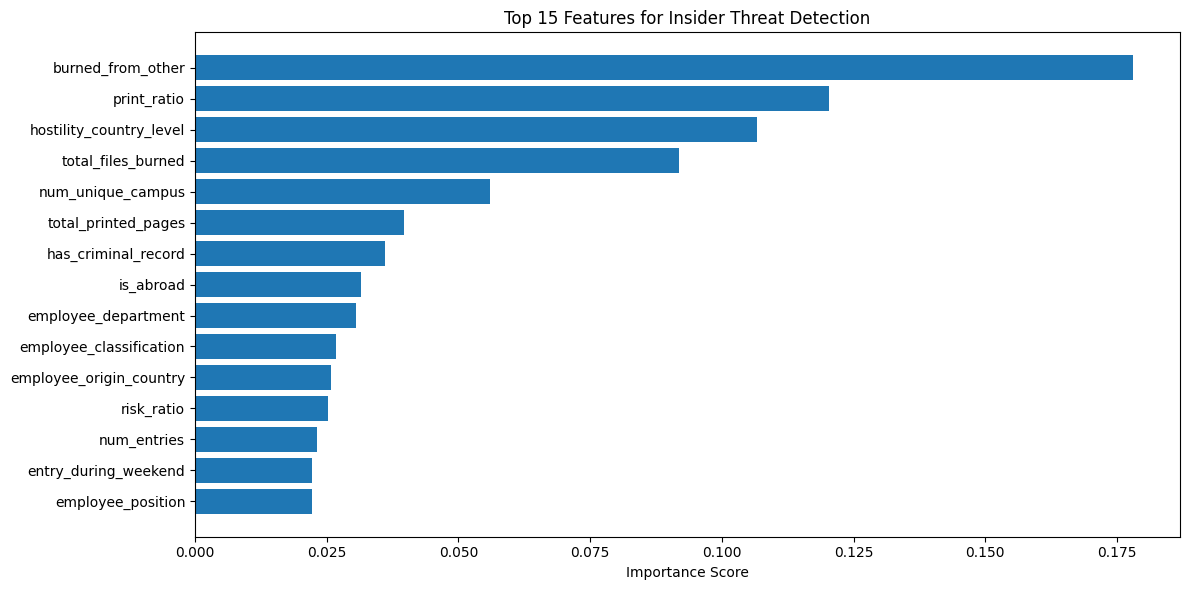

In [84]:
feat_imp = pd.DataFrame({
    'feature': feature_columns,
    'importance': xg_boost.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Features:")
print(feat_imp.head(10).to_string(index=False))

plt.figure(figsize=(12, 6))
plt.barh(feat_imp['feature'].head(15)[::-1],
         feat_imp['importance'].head(15)[::-1])
plt.xlabel('Importance Score')
plt.title('Top 15 Features for Insider Threat Detection')
plt.tight_layout()
plt.show()

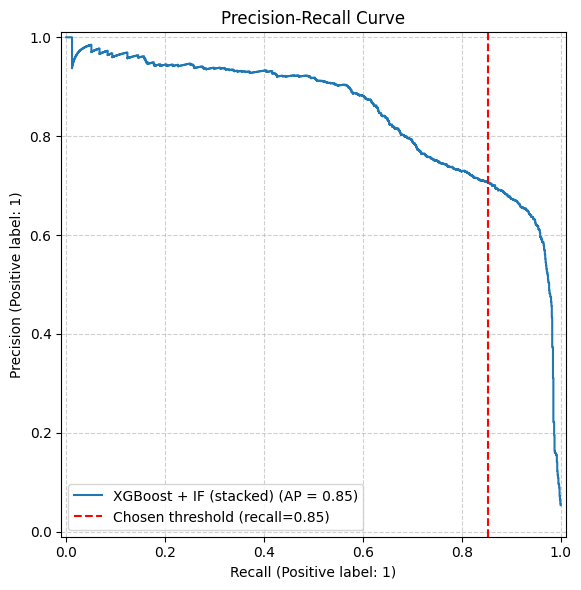

In [85]:
#PR Curve
fig, ax = plt.subplots(figsize=(8, 6))
PrecisionRecallDisplay.from_predictions(y_test, test_probs, ax=ax, name="XGBoost + IF (stacked)")
ax.axvline(x=recall, color='red', linestyle='--', label=f'Chosen threshold (recall={recall:.2f})')
ax.set_title("Precision-Recall Curve")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [86]:
import shap
shap.initjs()
explainer = shap.TreeExplainer(xg_boost)

X_test_df = pd.DataFrame(x_append_test, columns=feature_columns)
X_shap    = X_test_df.sample(n=min(1000, len(X_test_df)), random_state=42)
shap_values = explainer.shap_values(X_shap)
print("SHAP values computed.")

SHAP values computed.


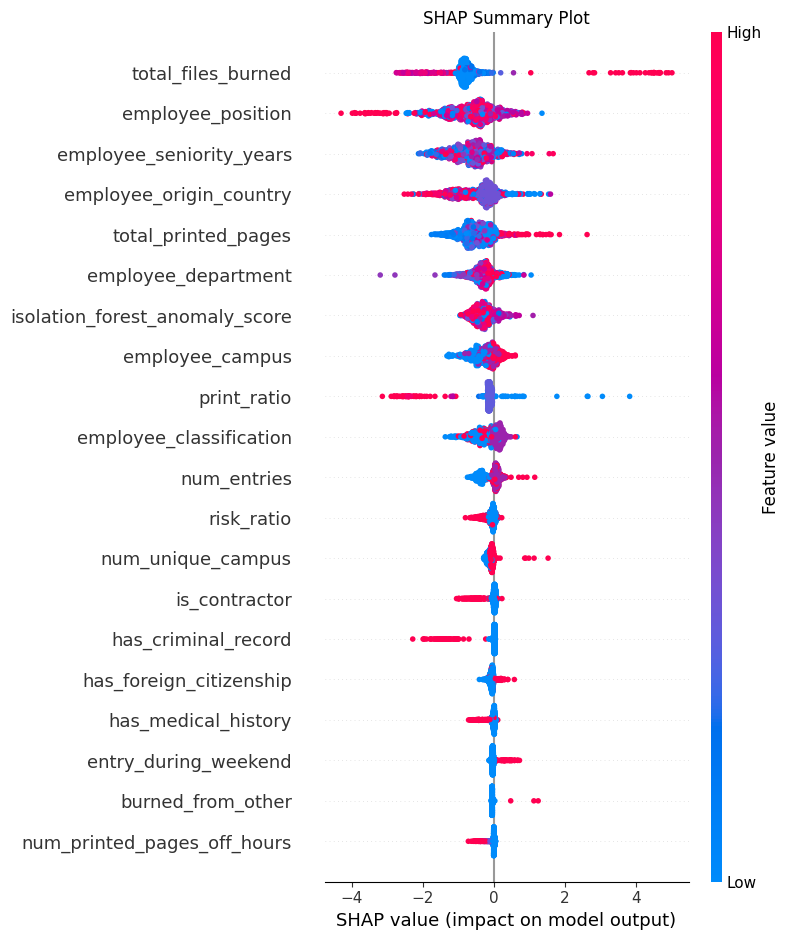

Force plot — instance index: 416
Dependence plot for: burned_from_other


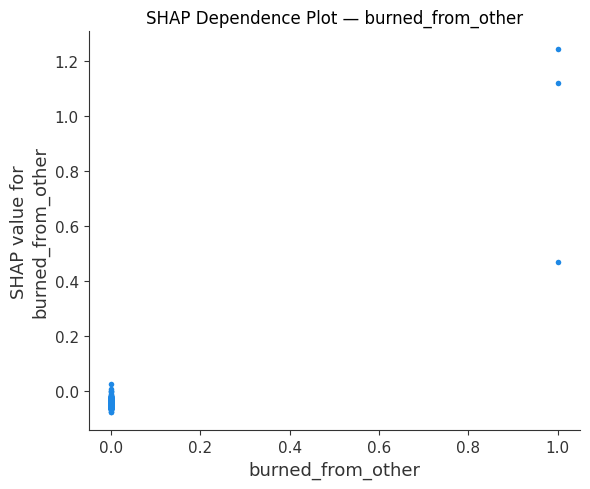

In [87]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, plot_type="dot", show=False)
plt.title('SHAP Summary Plot')
plt.tight_layout()
plt.show()

# Force plot for a random instance
instance_idx = np.random.randint(0, len(X_shap))
print(f"Force plot — instance index: {instance_idx}")
shap.force_plot(explainer.expected_value, shap_values[instance_idx], X_shap.iloc[instance_idx])

# Dependence plot for the most important feature
top_feature = feat_imp['feature'].iloc[0]
print(f"Dependence plot for: {top_feature}")
shap.dependence_plot(top_feature, shap_values, X_shap, interaction_index=None, show=False)
plt.title(f'SHAP Dependence Plot — {top_feature}')
plt.tight_layout()
plt.show()

In [88]:
# After your split, reset index but keep the original as a column
X_test_original_idx = x_test.index  # save original df index before any numpy conversion

# Then in sample analysis, look up using the original index
sample_idx = np.random.randint(0, len(x_append_test))
original_df_idx = X_test_original_idx[sample_idx]   # maps positional → original

sample_true = y_test.iloc[sample_idx]               # positional, matches X_test_aug
sample_true_verify = df.loc[original_df_idx, 'is_malicious']  # verify against df

print(f"Positional index in test set: {sample_idx}")
print(f"Original CSV row index:       {original_df_idx}")
print(f"True label (y_test):          {sample_true}")
print(f"True label (df verify):       {sample_true_verify}")  # these should now match

Positional index in test set: 15938
Original CSV row index:       90153
True label (y_test):          0
True label (df verify):       0


In [89]:
print("\n" + "=" * 50)
print("SAMPLE RECORD ANALYSIS")
print("=" * 50)

# Generate a random index for a sample in the test set
sample_idx  = np.random.randint(0, len(x_append_test)) # Re-added

# Get the original index from the full dataset for display purposes
# x_test.index stores the original DataFrame indices for the test set rows
original_df_idx = x_test.index[sample_idx] # Defined

# Select the augmented sample (features + IF score) for prediction
# Use slicing `[sample_idx:sample_idx+1]` to maintain a 2D array shape (1, num_features)
sample_aug  = x_append_test[sample_idx:sample_idx+1] # Corrected

# Get the true label for this sample
sample_true = y_test.iloc[sample_idx]

# Predict probability and class using the XGBoost model
sample_prob  = xg_boost.predict_proba(sample_aug)[:, 1][0]
sample_pred  = (sample_prob >= best_threshold).astype(int)

# Get the Isolation Forest anomaly score for this sample
sample_if_score = test_anomaly[sample_idx][0] # Corrected from test_if_score

print(f"Record index:  {original_df_idx}")
print(f"True label:    {'Malicious' if sample_true == 1 else 'Normal'}")
print(f"XGBoost prob:  {sample_prob:.4f}")
print(f"IF score:      {sample_if_score:.4f}  (lower = more anomalous)")
print(f"Prediction:    {'Malicious' if sample_pred == 1 else 'Normal'}")

# Reverse-transform for human-readable feature values
original_vals = {}

# Inverse transform numerical features using the scaler and x_test
inv_num = scaler.inverse_transform(x_test[num_cols].iloc[[sample_idx]])[0] # Corrected X_test to x_test
for i, col in enumerate(num_cols):
    original_vals[col] = inv_num[i]

# Inverse transform categorical features using label encoders and x_test
for col in cat_cols:
    enc_val = int(x_test[col].iloc[sample_idx]) # Corrected X_test to x_test
    original_vals[col] = label_encoders[col].inverse_transform([enc_val])[0]

# Get binary feature values from x_test
for col in bin_cols:
    original_vals[col] = x_test[col].iloc[sample_idx] # Corrected X_test to x_test

print("\nTop 10 features for this record:")
for feat in feat_imp['feature'].head(10):
    if feat == 'isolation_forest_score':
        print(f"  {feat}: {sample_if_score:.4f}")
    elif feat in original_vals:
        val = original_vals[feat]
        if feat in ['employee_seniority_years', 'total_printed_pages', 'num_printed_pages_off_hours',
                    'total_files_burned', 'trip_day_number', 'num_entries', 'num_unique_campus']:
            val = int(round(val))
        print(f"  {feat}: {val}")

print("\n--- Explanation ---")
if sample_pred == 1:
    print(f"Flagged as Malicious (prob={sample_prob:.4f} ≥ threshold={best_threshold:.4f}).")
    if sample_if_score < 0:
        print("The Isolation Forest also rated this record as anomalous (negative IF score).")
else:
    print(f"Classified as Normal (prob={sample_prob:.4f} < threshold={best_threshold:.4f}).")
    print("No strong anomaly signal detected by either model.")


SAMPLE RECORD ANALYSIS
Record index:  105514
True label:    Normal
XGBoost prob:  0.0015
IF score:      0.0530  (lower = more anomalous)
Prediction:    Normal

Top 10 features for this record:
  burned_from_other: 0
  print_ratio: 4.333333333333333
  hostility_country_level: 0.0
  total_files_burned: 37
  num_unique_campus: 1
  total_printed_pages: 0
  has_criminal_record: 0
  is_abroad: 0
  employee_department: Information Technology
  employee_classification: 3

--- Explanation ---
Classified as Normal (prob=0.0015 < threshold=0.6691).
No strong anomaly signal detected by either model.


In [91]:
model_package = {
    'xgb_model':      xg_boost,
    'iso_forest':     isolation_forest,
    'scaler':         scaler,
    'label_encoders': label_encoders,
    'feature_columns': feature_columns,
    'cat_cols':       cat_cols,
    'bin_cols':       bin_cols,
    'num_cols':       num_cols,
    'best_threshold': best_threshold,
    'feat_importance': feat_imp,
}

with open('insider_threat_model.pkl', 'wb') as f:
    pickle.dump(model_package, f)

print("\nModel package saved to 'insider_threat_model.pkl'")


Model package saved to 'insider_threat_model.pkl'
